In [23]:
!mv /kaggle/input/features/pytorch/size80/1 /kaggle/working

mv: cannot remove '/kaggle/input/features/pytorch/size80/1/train_features/train_features/features/config.json': Read-only file system
mv: cannot remove '/kaggle/input/features/pytorch/size80/1/train_features/train_features/features/labels/img_0054_hvflip.npy': Read-only file system
mv: cannot remove '/kaggle/input/features/pytorch/size80/1/train_features/train_features/features/labels/img_0622_hflip.npy': Read-only file system
mv: cannot remove '/kaggle/input/features/pytorch/size80/1/train_features/train_features/features/labels/img_0663_hflip.npy': Read-only file system
mv: cannot remove '/kaggle/input/features/pytorch/size80/1/train_features/train_features/features/labels/img_0383_vflip.npy': Read-only file system
mv: cannot remove '/kaggle/input/features/pytorch/size80/1/train_features/train_features/features/labels/img_0369_original.npy': Read-only file system
mv: cannot remove '/kaggle/input/features/pytorch/size80/1/train_features/train_features/features/labels/img_0151_hflip.np

In [24]:
import os, json, random, subprocess
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from typing import Callable
from itertools import chain

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.parallel import DataParallel

import torchvision
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold
from sklearn.metrics import f1_score, confusion_matrix, classification_report, precision_recall_fscore_support

import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

import timm

try: 
    from torchmil.models import MILModel
    from torchmil.nn import AttentionPool
    from torchmil.datasets import ProcessedMILDataset
    from torchmil.data import collate_fn as mil_collate_fn
except: 
    !pip install -q torchmil
    from torchmil.models import MILModel
    from torchmil.nn import AttentionPool
    from torchmil.datasets import ProcessedMILDataset
    from torchmil.data import collate_fn as mil_collate_fn

try:
    from huggingface_hub import login
except:
    !pip install -q huggingface_hub
    from huggingface_hub import login

import optuna
from optuna.visualization import plot_param_importances

import warnings
warnings.filterwarnings('ignore')

# Configuration
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_GPUS = torch.cuda.device_count() if torch.cuda.is_available() else 0
MULTIPLE_GPUS = NUM_GPUS > 1
USE_MULTI_GPU_FEATURES = MULTIPLE_GPUS

KAGGLE = True
if KAGGLE:
    BASE_DIR = "/kaggle/input/grumpy-doctogres/patches_80"
    TRAIN_IMG_DIR = os.path.join(BASE_DIR, "train", "imgs")
    TRAIN_MASK_DIR = os.path.join(BASE_DIR, "train", "masks")
    TEST_IMG_DIR = os.path.join(BASE_DIR, "test", "imgs")
    TEST_MASK_DIR = os.path.join(BASE_DIR, "test", "masks")
    TRAIN_LABELS_PATH = os.path.join(BASE_DIR, "train_labels.csv")
    FEATURES_DIR = Path("/kaggle/working/features")
    TEST_FEATURES_DIR = Path("/kaggle/working/1/test_features/test_features/test_features")
    STUDY_PATH = "/kaggle/working/optuna-studies"
else:
    BASE_DIR = "./data"
    TRAIN_IMG_DIR = os.path.join(BASE_DIR, "train", "imgs")
    TRAIN_MASK_DIR = os.path.join(BASE_DIR, "train", "masks")
    TEST_IMG_DIR = os.path.join(BASE_DIR, "test", "imgs")
    TEST_MASK_DIR = os.path.join(BASE_DIR, "test", "masks")
    TRAIN_LABELS_PATH = os.path.join(BASE_DIR, "train_labels.csv")
    FEATURES_DIR = Path("./features")
    TEST_FEATURES_DIR = Path("./test_features")
    STUDY_PATH = "./optuna-studies"

MODEL_DIR = "./models"
os.makedirs(MODEL_DIR, exist_ok=True)
FEATURES_DIR.mkdir(parents=True, exist_ok=True)
TEST_FEATURES_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ['HER2(+)', 'Luminal A', 'Luminal B', 'Triple negative']
NUM_CLASSES = len(CLASS_NAMES)
CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {idx: name for idx, name in enumerate(CLASS_NAMES)}
IMAGENET_MEAN, IMAGENET_STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
RESNET_INPUT_SIZE = 224

FEN_BATCH_SIZE = 65536
MIL_BATCH_SIZE = 256
K_FOLDS = 5
F1_TYPE = 'micro'

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

seed_everything(SEED)

def get_base_model(model):
    return model.module if isinstance(model, DataParallel) else model

print(f"Device: {DEVICE} | GPUs: {NUM_GPUS} | Classes: {NUM_CLASSES}")

Device: cuda | GPUs: 2 | Classes: 4


In [12]:
from kaggle_secrets import UserSecretsClient

try:
    hf_token = UserSecretsClient().get_secret("HUGGINGFACE_TOKEN")
    login(token=hf_token)
    print("Logged in to Hugging Face successfully.")
except Exception as e:
    print(f"Authentication warning: {e}")
    print("Ensure you have set the 'HUGGINGFACE_TOKEN' secret to access UNI2-h.")

Logged in to Hugging Face successfully.


In [ ]:
def get_original_image_id(img_name):
    name = os.path.splitext(img_name)[0]
    ext = os.path.splitext(img_name)[1]
    return (name.split('_r')[0] + ext) if '_r' in name else img_name

def get_mask_path(img_path, mask_dir):
    name = os.path.basename(img_path)
    mask_name = 'mask_' + name[4:] if name.startswith('img_') else name
    return os.path.join(mask_dir, mask_name)

def load_train_data(img_dir, mask_dir, labels_path):
    labels_df = pd.read_csv(labels_path)
    label_lookup = {row.iloc[0]: CLASS_TO_IDX[row.iloc[1]] for _, row in labels_df.iterrows()}
    
    img_paths, mask_paths, labels, orig_indices = [], [], [], []
    for name in sorted(os.listdir(img_dir)):
        if not name.endswith(('.png', '.jpg', '.jpeg')): continue
        img_path = os.path.join(img_dir, name)
        mask_path = get_mask_path(img_path, mask_dir)
        orig_id = get_original_image_id(name)
        if orig_id not in label_lookup or not os.path.exists(mask_path): continue
        img_paths.append(img_path)
        mask_paths.append(mask_path)
        labels.append(label_lookup[orig_id])
        orig_indices.append(orig_id)
    
    return np.array(img_paths), np.array(mask_paths), np.array(labels), np.array(orig_indices), label_lookup

def load_test_data(img_dir, mask_dir):
    img_paths, mask_paths, names, orig_indices = [], [], [], []
    for name in sorted(os.listdir(img_dir)):
        if not name.endswith(('.png', '.jpg', '.jpeg')): continue
        img_path = os.path.join(img_dir, name)
        mask_path = get_mask_path(img_path, mask_dir)
        if not os.path.exists(mask_path): continue
        img_paths.append(img_path)
        mask_paths.append(mask_path)
        names.append(name)
        orig_indices.append(get_original_image_id(name))
    return np.array(img_paths), np.array(mask_paths), np.array(names), np.array(orig_indices)

def get_bag_names(orig_indices):
    return [img_id.replace('.png', '').replace('.jpg', '') for img_id in np.unique(orig_indices)]

def get_image_labels(orig_indices, label_lookup):
    unique = np.unique(orig_indices)
    return unique, np.array([label_lookup[img_id] for img_id in unique])

try:
    train_img_paths, train_mask_paths, train_labels, train_orig_indices, image_label_lookup = load_train_data(
        TRAIN_IMG_DIR, TRAIN_MASK_DIR, TRAIN_LABELS_PATH)
    unique_images, unique_labels = get_image_labels(train_orig_indices, image_label_lookup)
    print(f"Training: {len(train_img_paths)} patches, {len(unique_images)} images")
    print("Class distribution:", dict(zip(CLASS_NAMES, np.bincount(unique_labels, minlength=NUM_CLASSES))))
except Exception as e:
    print(f"Could not load training data: {e}")
    train_img_paths, train_mask_paths, train_labels, train_orig_indices = np.array([]), np.array([]), np.array([]), np.array([])
    image_label_lookup = {}

Training: 6689 patches, 581 images
Class distribution: {'HER2(+)': 150, 'Luminal A': 158, 'Luminal B': 204, 'Triple negative': 69}


In [14]:
class DeterministicAugTransform:
    AUGMENTATIONS = {
        'original': {},
        'augmix': {'augmix': True, 'severity': 3, 'mixture_width': 3, 'alpha': 1.0},
        'hflip': {'hflip': True}, 'vflip': {'vflip': True}, 'hvflip': {'hflip': True, 'vflip': True},
        'rot90': {'rotation': 90}, 'rot180': {'rotation': 180}, 'rot270': {'rotation': 270}
    }
    '''
        'hflip_rot90': {'hflip': True, 'rotation': 90}, 'hflip_rot180': {'hflip': True, 'rotation': 180},
        'hflip_rot270': {'hflip': True, 'rotation': 270}, 'vflip_rot90': {'vflip': True, 'rotation': 90},
        'vflip_rot180': {'vflip': True, 'rotation': 180}, 'vflip_rot270': {'vflip': True, 'rotation': 270},
    '''
    
    @classmethod
    def get_all_names(cls): return list(cls.AUGMENTATIONS.keys())
    
    def __init__(self, aug_type='original', size=RESNET_INPUT_SIZE):
        self.config = self.AUGMENTATIONS.get(aug_type, {})
        self.size = size
    
    def __call__(self, img_path):
        img = Image.open(img_path).convert('RGB')
        if self.config.get('hflip'): img = transforms.functional.hflip(img)
        if self.config.get('vflip'): img = transforms.functional.vflip(img)
        if rot := self.config.get('rotation'): img = transforms.functional.rotate(img, rot)
        if self.config.get('augmix'):
            img = transforms.AugMix(
                severity=self.config.get('severity', 3),
                mixture_width=self.config.get('mixture_width', 3),
                alpha=self.config.get('alpha', 1.0)
            )(img)
        tensor = transforms.functional.to_tensor(img)
        tensor = transforms.functional.normalize(tensor, IMAGENET_MEAN, IMAGENET_STD)
        return transforms.functional.resize(tensor, (self.size, self.size))


def filter_augmentations(available, aug_params=None):
    aug_params = aug_params or {}
    selected = ['original']
    if aug_params.get('use_hflip') and 'hflip' in available: selected.append('hflip')
    if aug_params.get('use_vflip') and 'vflip' in available: selected.append('vflip')
    if aug_params.get('use_hflip') and aug_params.get('use_vflip') and 'hvflip' in available: selected.append('hvflip')
    if aug_params.get('use_rotation'):
        for r in ['rot90', 'rot180', 'rot270']:
            if r in available: selected.append(r)
    if aug_params.get('use_flip_rotation_combos'):
        for c in ['hflip_rot90', 'hflip_rot180', 'hflip_rot270', 'vflip_rot90', 'vflip_rot180', 'vflip_rot270']:
            if c in available: selected.append(c)
    if aug_params.get('use_augmix') and 'augmix' in available: selected.append('augmix')
    return list(dict.fromkeys(selected))


def create_mil_dataloaders(features_dir, labels_dir, train_names, val_names, augmentations=None, batch_size=MIL_BATCH_SIZE):
    """Create train/val MIL dataloaders using torchmil ProcessedMILDataset."""
    # For training: include augmented versions
    train_bag_names = []
    for name in train_names:
        for aug in (augmentations or ['original']):
            train_bag_names.append(f"{name}_{aug}")
    
    # For validation: only original
    val_bag_names = [f"{name}_original" for name in val_names]
    
    train_ds = ProcessedMILDataset(
        features_path=str(features_dir),
        labels_path=str(labels_dir),
        bag_keys=["X", "Y"],
        bag_names=train_bag_names,
        load_at_init=False
    )
    val_ds = ProcessedMILDataset(
        features_path=str(features_dir),
        labels_path=str(labels_dir),
        bag_keys=["X", "Y"],
        bag_names=val_bag_names,
        load_at_init=False
    )
    
    return (DataLoader(train_ds, batch_size, shuffle=True, collate_fn=mil_collate_fn, pin_memory=True),
            DataLoader(val_ds, batch_size, shuffle=False, collate_fn=mil_collate_fn, pin_memory=True))

print("Transforms and datasets ready (using torchmil ProcessedMILDataset).")

Transforms and datasets ready (using torchmil ProcessedMILDataset).


In [15]:
class GradCAMPlusPlus:
    def __init__(self, model, target_layer=None):
        self.model = model
        self.gradients = self.activations = None
        self.handles = []
        base_model = get_base_model(model)
        self.target_layer = target_layer or base_model.rgb_features[-1]
        self._register_hooks()
    
    def _register_hooks(self):
        def forward_hook(m, i, o): self.activations = o.detach()
        def backward_hook(m, gi, go): self.gradients = go[0].detach()
        self.handles = [self.target_layer.register_forward_hook(forward_hook),
                       self.target_layer.register_full_backward_hook(backward_hook)]
    
    def remove_hooks(self):
        for h in self.handles: h.remove()
    
    def __call__(self, input_tensor, target_class=None):
        self.model.eval()
        output = self.model(input_tensor)
        logits = output[0] if isinstance(output, tuple) else output
        probs = F.softmax(logits, dim=1)
        target_class = target_class if target_class is not None else logits.argmax(dim=1).item()
        
        self.model.zero_grad()
        one_hot = torch.zeros_like(logits); one_hot[0, target_class] = 1
        logits.backward(gradient=one_hot, retain_graph=True)
        
        grad_2, grad_3 = self.gradients ** 2, self.gradients ** 3
        alpha = grad_2 / (2 * grad_2 + (self.activations * grad_3).sum((2,3), keepdim=True) + 1e-8)
        weights = (alpha * F.relu(self.gradients)).sum((2,3), keepdim=True)
        heatmap = F.relu((weights * self.activations).sum(1, keepdim=True)).squeeze().cpu().numpy()
        heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
        return heatmap, target_class, probs[0].detach().cpu().numpy()


class CAMResNet(nn.Module):
    """Two-Tower UNI2-h with Gated Fusion: Tower A (RGB) + Tower B (Mask) → CAM Head."""
    def __init__(self, num_classes=NUM_CLASSES, model_params=None, freeze_backbone=True):
        super().__init__()
        model_params = model_params or {}
        self.num_classes, self.freeze_backbone = num_classes, freeze_backbone
        
        feature_dim = model_params.get('feature_dim', 256)
        hidden_channels = model_params.get('hidden_channels', 256)
        dropout_rate = model_params.get('dropout_rate', 0.3)
        mask_channels = model_params.get('mask_channels', [32, 64, 128])
        
        # Load UNI2-h backbone
        print("Loading UNI2-h backbone...")
        timm_kwargs = {
            'img_size': 224, 
            'patch_size': 14, 
            'depth': 24,
            'num_heads': 24,
            'init_values': 1e-5, 
            'embed_dim': 1536,
            'mlp_ratio': 2.66667*2,
            'num_classes': 0, 
            'no_embed_class': True,
            'mlp_layer': timm.layers.SwiGLUPacked, 
            'act_layer': torch.nn.SiLU, 
            'reg_tokens': 8, 
            'dynamic_img_size': True
        }
        uni2h_model = timm.create_model("hf-hub:MahmoodLab/UNI2-h", pretrained=True, **timm_kwargs)
        
        # The UNI2-h model outputs 1536-dim features directly
        # We'll use it as-is for RGB tower
        self.rgb_features = uni2h_model
        self.uni2h_feature_dim = uni2h_model.num_features  # 1536
        
        if freeze_backbone:
            for p in self.rgb_features.parameters(): p.requires_grad = False
        
        # RGB projection (from 1536 to feature_dim)
        self.rgb_proj = nn.Sequential(nn.Linear(self.uni2h_feature_dim, feature_dim), nn.ReLU(True), 
                                       nn.Dropout(dropout_rate) if dropout_rate > 0 else nn.Identity())
        
        # Mask tower (unchanged)
        layers = []
        in_ch = 1
        for out_ch in mask_channels:
            layers.extend([nn.Conv2d(in_ch, out_ch, 3, 2, 1), nn.BatchNorm2d(out_ch), nn.ReLU(True)])
            in_ch = out_ch
        self.mask_features = nn.Sequential(*layers)
        self.mask_pool = nn.AdaptiveAvgPool2d(1)
        self.mask_proj = nn.Sequential(nn.Linear(mask_channels[-1], feature_dim), nn.ReLU(True),
                                        nn.Dropout(dropout_rate) if dropout_rate > 0 else nn.Identity())
        
        # Fusion gate (unchanged)
        self.fusion_gate = nn.Sequential(nn.Linear(feature_dim * 2, feature_dim), nn.Sigmoid())
        
        # For CAM head, we need spatial features - UNI2-h outputs global features
        # So we'll create a simple spatial representation using the fused features
        self.cam_head = nn.Sequential(
            nn.Conv2d(feature_dim, hidden_channels, 3, 1, 1), nn.BatchNorm2d(hidden_channels), nn.ReLU(True), nn.Dropout2d(dropout_rate),
            nn.Conv2d(hidden_channels, hidden_channels // 2, 3, 1, 1), nn.BatchNorm2d(hidden_channels // 2), nn.ReLU(True), nn.Dropout2d(dropout_rate),
            nn.Conv2d(hidden_channels // 2, num_classes, 1))
        self.fusion_to_spatial = nn.Sequential(nn.Linear(feature_dim, feature_dim * 7 * 7), nn.Sigmoid())
        self.global_max_pool = nn.AdaptiveMaxPool2d(1)
        self.fused_classifier = nn.Linear(feature_dim, num_classes)
    
    def forward(self, x, return_heatmaps=False):
        rgb, mask = x[:, :3], x[:, 3:4]
        
        # UNI2-h processes RGB and outputs global features
        rgb_global = self.rgb_features(rgb)  # (B, 1536)
        f_img = self.rgb_proj(rgb_global)  # (B, feature_dim)
        
        # Mask tower (unchanged)
        f_mask = self.mask_proj(self.mask_pool(self.mask_features(mask)).view(x.size(0), -1))
        
        # Fusion (unchanged)
        gate = self.fusion_gate(torch.cat([f_img, f_mask], 1))
        fused = gate * f_img + (1 - gate) * f_mask
        
        # Create spatial representation for CAM
        spatial_fused = self.fusion_to_spatial(fused).view(-1, fused.size(1), 7, 7)
        heatmaps = self.cam_head(spatial_fused)
        
        # Final logits
        logits = 0.5 * self.global_max_pool(heatmaps).view(x.size(0), -1) + 0.5 * self.fused_classifier(fused)
        return (logits, heatmaps) if return_heatmaps else logits
    
    def unfreeze_backbone(self, num_layers=-1):
        children = list(self.rgb_features.children())
        for child in (children if num_layers == -1 else children[-num_layers:]):
            for p in child.parameters(): p.requires_grad = True
        self.freeze_backbone = False
    
    def get_trainable_params(self): return sum(p.numel() for p in self.parameters() if p.requires_grad)
    def get_gradcam_plusplus(self, layer=None): return GradCAMPlusPlus(self, layer)


def create_model(model_params=None, freeze_backbone=True, use_multi_gpu=False):
    model = CAMResNet(NUM_CLASSES, model_params, freeze_backbone).to(DEVICE)
    if use_multi_gpu and MULTIPLE_GPUS: model = DataParallel(model)
    return model

print("Two-Tower CAMResNet with UNI2-h + GradCAM++ ready.")

Two-Tower CAMResNet with UNI2-h + GradCAM++ ready.


In [16]:
class MultiClassABMIL(MILModel):
    """Attention-Based MIL using torchmil's AttentionPool."""
    def __init__(self, in_dim, num_classes, att_dim=128, hidden_dim=256, att_act='tanh', 
                 gated=True, dropout=0.3):
        super().__init__()
        
        self.feature_transform = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        self.pool = AttentionPool(in_dim=hidden_dim, att_dim=att_dim, act=att_act, gated=gated)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, num_classes)
    
    def forward(self, X, mask=None, return_attention=False):
        """
        X: (B, N, D) - Patch features
        mask: (B, N) - Attention mask (which patches are valid)
        """
        X_transformed = self.feature_transform(X)
        Z = self.pool(X_transformed, mask)
        Z = self.dropout(Z)
        logits = self.classifier(Z)
        
        if return_attention:
            # Compute attention weights for visualization
            with torch.no_grad():
                if self.pool.gated:
                    # Gated attention: use attention_V, attention_U, attention_w
                    A_V = self.pool.attention_V(X_transformed)
                    A_U = self.pool.attention_U(X_transformed)
                    A = self.pool.attention_w(A_V * A_U).squeeze(-1)
                else:
                    # Non-gated attention: use fc1 and fc2
                    A = self.pool.fc2(torch.tanh(self.pool.fc1(X_transformed))).squeeze(-1)
                
                if mask is not None:
                    A = A.masked_fill(~mask, -1e9)
                attn = F.softmax(A, dim=1)
            return logits, attn
        return logits
    
    def get_trainable_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


def create_mil_model(feature_dim, mil_params=None, use_multi_gpu=False):
    mil_params = mil_params or {}
    model = MultiClassABMIL(
        in_dim=feature_dim,
        att_dim=mil_params.get('att_dim', 128),
        hidden_dim=mil_params.get('hidden_dim', 256),
        gated=mil_params.get('gated', True),
        dropout=mil_params.get('dropout', 0.3),
        num_classes=NUM_CLASSES
    ).to(DEVICE)
    
    if use_multi_gpu and MULTIPLE_GPUS:
        model = DataParallel(model)
    
    return model

print("MIL model ready (using torchmil AttentionPool).")

MIL model ready (using torchmil AttentionPool).


In [17]:
class FeatureExtractor(nn.Module):
    def __init__(self, device=DEVICE, use_multi_gpu=False):
        super().__init__()
        print("Initializing UNI2-h feature extractor...")
        timm_kwargs = {
            'img_size': 224, 
            'patch_size': 14, 
            'depth': 24,
            'num_heads': 24,
            'init_values': 1e-5, 
            'embed_dim': 1536,
            'mlp_ratio': 2.66667*2,
            'num_classes': 0, 
            'no_embed_class': True,
            'mlp_layer': timm.layers.SwiGLUPacked, 
            'act_layer': torch.nn.SiLU, 
            'reg_tokens': 8, 
            'dynamic_img_size': True
        }
        backbone = timm.create_model("hf-hub:MahmoodLab/UNI2-h", pretrained=True, **timm_kwargs)
        self.feature_dim = backbone.num_features  # 1536 for UNI2-h

        for p in backbone.parameters():
            p.requires_grad = False

        self.device = device
        self.use_multi_gpu = use_multi_gpu and MULTIPLE_GPUS
        if self.use_multi_gpu:
            self.features = DataParallel(backbone).to(device)
            print(f"UNI2-h loaded across {NUM_GPUS} GPUs for feature extraction")
        else:
            self.features = backbone.to(device)
            print("UNI2-h loaded on single device for feature extraction")
        self.features.eval()
        print(f"UNI2-h ready. Feature dimension: {self.feature_dim}")
    
    def forward(self, rgb): 
        with torch.no_grad(): 
            features = self.features(rgb)
            return features
    
    def extract_features(self, rgb):
        return self.forward(rgb)


def extract_and_cache_features(image_paths, original_indices, label_lookup, extractor, output_dir, augmentations, batch_size=FEN_BATCH_SIZE, device=DEVICE):
    output_dir = Path(output_dir)
    (features_dir := output_dir / 'features').mkdir(parents=True, exist_ok=True)
    (labels_dir := output_dir / 'labels').mkdir(parents=True, exist_ok=True)
    device = getattr(extractor, 'device', device)
    
    unique_images = np.unique(original_indices)
    aug_names = [a[0] for a in augmentations]
    print(f"Extracting features for {len(unique_images)} images, {len(augmentations)} augmentations...")
    print(f"  UNI2-h backbone: {extractor.feature_dim}-dim vectors")
    print(f"  Output directory: {output_dir}")
    
    for img_id in tqdm(unique_images, desc="Extracting"):
        bag_name = img_id.replace('.png', '').replace('.jpg', '')
        
        # Save label (same for all augmentations of this bag)
        label_file = labels_dir / f'{bag_name}.npy'
        if not label_file.exists(): 
            np.save(label_file, np.array([label_lookup.get(img_id, 0)]))
        
        img_paths = image_paths[original_indices == img_id]
        for aug_name, transform in augmentations:
            feat_file = features_dir / f'{bag_name}_{aug_name}.npy'
            if feat_file.exists(): continue
            
            all_feats = []
            for i in range(0, len(img_paths), batch_size):
                batch = torch.stack([transform(p) for p in img_paths[i:i+batch_size]]).to(device)
                with torch.no_grad(): 
                    feats = extractor.extract_features(batch)
                    all_feats.append(feats.cpu().numpy())
            
            stacked_feats = np.concatenate(all_feats, 0)
            np.save(feat_file, stacked_feats)
            
            # Also save label with augmentation name for torchmil ProcessedMILDataset
            aug_label_file = labels_dir / f'{bag_name}_{aug_name}.npy'
            if not aug_label_file.exists():
                np.save(aug_label_file, np.array([label_lookup.get(img_id, 0)]))
    
    config = {
        'feature_dim': extractor.feature_dim,
        'backbone': 'uni2-h',
        'augmentations': aug_names,
        'feature_shape': f'[N, {extractor.feature_dim}]'
    }
    with open(output_dir / 'config.json', 'w') as f:
        json.dump(config, f, indent=2)
    print(f"✅ Features saved to {output_dir}")
    return output_dir


def extract_test_features(image_paths, original_indices, extractor, output_dir, augmentations=None, batch_size=FEN_BATCH_SIZE, device=DEVICE):
    output_dir = Path(output_dir)
    (features_dir := output_dir / 'features').mkdir(parents=True, exist_ok=True)
    device = getattr(extractor, 'device', device)
    
    augmentations = augmentations or [('original', DeterministicAugTransform('original'))]
    unique_images = np.unique(original_indices)
    aug_names = [a[0] for a in augmentations]
    
    print(f"Extracting test features for {len(unique_images)} images, {len(augmentations)} augmentations...")
    print(f"  UNI2-h backbone: {extractor.feature_dim}-dim vectors")
    
    for img_id in tqdm(unique_images, desc="Test extraction"):
        bag_name = img_id.replace('.png', '').replace('.jpg', '')
        img_paths = image_paths[original_indices == img_id]
        
        for aug_name, transform in augmentations:
            feat_file = features_dir / f'{bag_name}_{aug_name}.npy'
            if feat_file.exists(): continue
            
            all_feats = []
            for i in range(0, len(img_paths), batch_size):
                batch = torch.stack([transform(p) for p in img_paths[i:i+batch_size]]).to(device)
                with torch.no_grad():
                    feats = extractor.extract_features(batch)
                    all_feats.append(feats.cpu().numpy())
            
            stacked_feats = np.concatenate(all_feats, 0)
            np.save(feat_file, stacked_feats)
    
    config = {
        'feature_dim': extractor.feature_dim,
        'backbone': 'uni2-h',
        'augmentations': aug_names,
        'feature_shape': f'[N, {extractor.feature_dim}]'
    }
    with open(output_dir / 'config.json', 'w') as f:
        json.dump(config, f, indent=2)


In [18]:
def doubling_frequency256(state):
    if "last_update" not in state:
        state["last_update"], state['precondition_frequency'] = 0, state.get('precondition_frequency', 10)
        return True
    if state['step'] - state['last_update'] >= state['precondition_frequency']:
        state['last_update'] = state['step']
        state['precondition_frequency'] = min(256, state['precondition_frequency'] * 2)
        return True
    return False

class SOAP(optim.Optimizer):
    def __init__(self, params, lr=3e-3, betas=(0.95, 0.95), shampoo_beta=-1, eps=1e-8, weight_decay=0.01,
                 precondition_frequency=10, precondition_frequency_routine=doubling_frequency256,
                 max_precond_dim=10000, merge_dims=False, precondition_1d=False, normalize_grads=False, correct_bias=True):
        defaults = dict(lr=lr, betas=betas, shampoo_beta=shampoo_beta, eps=eps, weight_decay=weight_decay,
                       precondition_frequency=precondition_frequency, precondition_frequency_routine=precondition_frequency_routine,
                       max_precond_dim=max_precond_dim, merge_dims=merge_dims, precondition_1d=precondition_1d,
                       normalize_grads=normalize_grads, correct_bias=correct_bias)
        super().__init__(params, defaults)

    def merge_dims(self, grad, max_precond_dim):
        shape, new_shape, curr = grad.shape, [], 1
        for sh in shape:
            if (temp := curr * sh) > max_precond_dim:
                if curr > 1: new_shape.append(curr); curr = sh
                else: new_shape.append(sh); curr = 1
            else: curr = temp
        if curr > 1 or not new_shape: new_shape.append(curr)
        return grad.reshape(new_shape)

    @torch.no_grad()
    def step(self, closure=None):
        loss = closure() if closure else None
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None: continue
                grad, state = p.grad, self.state[p]
                if "step" not in state: state["step"] = 0
                if "exp_avg" not in state:
                    state["exp_avg"] = torch.zeros_like(grad)
                    state["exp_avg_sq"] = torch.zeros_like(grad)
                if 'Q' not in state:
                    self._init_precond(grad, state, group); self._update_precond(grad, state, group); continue
                
                grad_proj = self._project(grad, state, group)
                beta1, beta2 = group["betas"]
                state["step"] += 1
                state["exp_avg"].mul_(beta1).add_(grad_proj, alpha=1-beta1)
                state["exp_avg_sq"].mul_(beta2).add_(grad_proj.square(), alpha=1-beta2)
                
                step_size = group["lr"]
                if group["correct_bias"]:
                    step_size *= (1 - beta2**state["step"])**0.5 / (1 - beta1**state["step"])
                
                norm_grad = self._project_back(state["exp_avg"] / (state["exp_avg_sq"].sqrt() + group["eps"]), state, group)
                if group["normalize_grads"]: norm_grad /= (1e-30 + (norm_grad**2).mean()**0.5)
                p.add_(norm_grad, alpha=-step_size)
                if group["weight_decay"] > 0: p.add_(p, alpha=-group["lr"] * group["weight_decay"])
                self._update_precond(grad, state, group)
        return loss

    def _init_precond(self, grad, state, group):
        state['GG'] = [torch.zeros(sh, sh, device=grad.device) if sh <= group['max_precond_dim'] else [] 
                       for sh in (self.merge_dims(grad, group['max_precond_dim']).shape if group['merge_dims'] else grad.shape)] if grad.dim() > 1 else \
                      ([torch.zeros(grad.shape[0], grad.shape[0], device=grad.device)] if group['precondition_1d'] and grad.shape[0] <= group['max_precond_dim'] else [[]])
        state['Q'], state['precondition_frequency'] = None, group['precondition_frequency']
        state['precondition_frequency_routine'], state['shampoo_beta'] = group['precondition_frequency_routine'], group['shampoo_beta'] if group['shampoo_beta'] >= 0 else group["betas"][1]

    def _project(self, grad, state, group):
        if group['merge_dims']: grad = self.merge_dims(grad, group['max_precond_dim'])
        for mat in state['Q']:
            grad = torch.tensordot(grad, mat, dims=[[0], [0]]) if len(mat) else grad.permute(list(range(1, grad.dim())) + [0])
        return grad

    def _project_back(self, grad, state, group):
        for mat in state['Q']:
            grad = torch.tensordot(grad, mat, dims=[[0], [1]]) if len(mat) else grad.permute(list(range(1, grad.dim())) + [0])
        return grad

    def _update_precond(self, grad, state, group):
        if state["Q"] is not None: state["exp_avg"] = self._project_back(state["exp_avg"], state, group)
        g = self.merge_dims(grad, group['max_precond_dim']) if group['merge_dims'] else grad
        for idx, (gg, sh) in enumerate(zip(state['GG'], g.shape)):
            if len(gg): gg.lerp_(torch.tensordot(g, g, dims=[[*range(idx), *range(idx+1, g.dim())]]*2), 1-state['shampoo_beta'])
        if state['Q'] is None:
            state['Q'] = [torch.flip(torch.linalg.eigh(m + 1e-30*torch.eye(m.shape[0], device=m.device))[1], [1]) if len(m) else [] for m in state['GG']]
        elif state['step'] > 0 and state['precondition_frequency_routine'](state):
            state['Q'] = [torch.linalg.qr(m @ o)[0] if len(m) else [] for m, o in zip(state['GG'], state['Q'])]
        if state["step"] > 0: state["exp_avg"] = self._project(state["exp_avg"], state, group)


def train_one_epoch_mil(model, loader, criterion, optimizer, scaler, device):
    model.train()
    total_loss, preds, labels, n = 0., [], [], 0
    for batch in loader:
        feats = batch['X'].to(device)
        lbls = batch['Y'].squeeze().long().to(device)
        mask = batch['mask'].to(device) if 'mask' in batch else None
        
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=device.type=='cuda'):
            logits = model(feats, mask)
            loss = criterion(logits, lbls)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer); torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        scaler.step(optimizer); scaler.update()
        total_loss += loss.item() * lbls.size(0); n += lbls.size(0)
        preds.extend(logits.argmax(1).cpu().numpy()); labels.extend(lbls.cpu().numpy())
    return total_loss / max(n, 1), f1_score(labels, preds, average=F1_TYPE) if labels else 0.


def validate_mil(model, loader, criterion, device, return_probs=False):
    model.eval()
    total_loss, preds, labels, probs, names, n = 0., [], [], [], [], 0
    with torch.no_grad():
        for batch in loader:
            feats = batch['X'].to(device)
            lbls = batch['Y'].squeeze().long().to(device)
            mask = batch['mask'].to(device) if 'mask' in batch else None
            
            with torch.amp.autocast('cuda', enabled=device.type=='cuda'):
                logits = model(feats, mask)
                if criterion: total_loss += criterion(logits, lbls).item() * lbls.size(0)
            n += lbls.size(0); p = F.softmax(logits, 1)
            preds.extend(logits.argmax(1).cpu().numpy()); labels.extend(lbls.cpu().numpy())
            probs.extend(p.cpu().numpy())
    loss = total_loss / max(n, 1); f1 = f1_score(labels, preds, average=F1_TYPE) if labels else 0.
    return (loss, f1, np.array(probs), np.array(labels), names) if return_probs else (loss, f1)


def train_mil_model(model, train_loader, val_loader, train_params, optimizer_params, fold_idx=0, verbose=10):
    criterion = nn.CrossEntropyLoss(weight=train_params.get('class_weights'), label_smoothing=train_params.get('label_smoothing', 0.1))
    optimizer = create_optimizer(model, optimizer_params)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', 0.5, train_params.get('patience', 20)//3, verbose=(verbose > 0))
    scaler = torch.amp.GradScaler(enabled=torch.cuda.is_available())
    
    history = {'train_loss': [], 'train_f1': [], 'val_loss': [], 'val_f1': []}
    best_f1, best_state, no_improve = 0., None, 0
    epochs = train_params.get('epochs', 100)
    patience = train_params.get('patience', 20)
    
    for epoch in range(1, epochs + 1):
        tr_loss, tr_f1 = train_one_epoch_mil(model, train_loader, criterion, optimizer, scaler, DEVICE)
        va_loss, va_f1 = validate_mil(model, val_loader, criterion, DEVICE)
        for k, v in zip(history.keys(), [tr_loss, tr_f1, va_loss, va_f1]): history[k].append(v)
        scheduler.step(va_f1)
        
        if verbose > 0 and (epoch % verbose == 0 or epoch == 1 or epoch == epochs):
            lr = optimizer.param_groups[0]['lr']
            print(f"  Epoch {epoch:03d}/{epochs} | lr={lr:.2e} | train_loss={tr_loss:.4f} train_F1={tr_f1:.4f} | val_loss={va_loss:.4f} val_F1={va_f1:.4f}")
        
        if va_f1 > best_f1:
            best_f1, best_state, no_improve = va_f1, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
            if verbose > 0: print(f"    ✅ New best F1: {best_f1:.4f}")
        else:
            no_improve += 1
            if no_improve >= patience:
                if verbose > 0: print(f"  Early stopping at epoch {epoch} (patience={patience})")
                break
    
    return best_state, best_f1, history


def create_optimizer(model, params):
    name = params.get('name', 'adamw').lower()
    lr, wd = params.get('lr', 1e-3), params.get('weight_decay', 0.01)
    learnable_params = filter(lambda p: p.requires_grad, model.parameters())
    if name == 'soap':
        return SOAP(learnable_params, lr=lr, weight_decay=wd, betas=(params.get('beta1', 0.95), params.get('beta2', 0.95)))
    elif name == 'adam':
        return optim.Adam(learnable_params, lr=lr, weight_decay=wd)
    return optim.AdamW(learnable_params, lr=lr, weight_decay=wd)


def wrap_model_multi_gpu(model, use_multi_gpu=True):
    if use_multi_gpu and MULTIPLE_GPUS:
        model = DataParallel(model)
        print(f"  Model wrapped with DataParallel across {NUM_GPUS} GPUs")
    return model

print("SOAP optimizer + MIL training utilities ready.")

SOAP optimizer + MIL training utilities ready.


In [19]:
def suggest_mil_hyperparameters(trial):
    mil_params = {
        'att_dim': trial.suggest_categorical('att_dim', [64, 128, 256, 512, 1024]),
        'hidden_dim': trial.suggest_categorical('hidden_dim', [128, 256, 512, 1024, 2048]),
        'gated': trial.suggest_categorical('gated', [True, False]),
        'dropout': trial.suggest_float('dropout', 0.1, 0.5)
    }
    
    optimizer_name = trial.suggest_categorical('optimizer', ['adamw', 'soap'])
    optimizer_params = {
        'name': optimizer_name,
        'lr': trial.suggest_float('lr', 1e-5, 1e-2, log=True),
        'weight_decay': trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)
    }
    
    #if optimizer_name == 'soap':
    #    optimizer_params['shampoo_beta'] = trial.suggest_float('shampoo_beta', 0.9, 0.999)
    #    optimizer_params['precondition_frequency'] = trial.suggest_int('precondition_frequency', 5, 20)
    
    train_params = {
        'epochs': 500, #trial.suggest_int('epochs', 400, 500),
        'patience': 25, #trial.suggest_int('patience', 50, 100),
        'label_smoothing': trial.suggest_float('label_smoothing', 0.0, 0.2),
        'use_class_weights': trial.suggest_categorical('use_class_weights', [True, False]),
        'grad_clip': 5.0 #trial.suggest_float('grad_clip', 0.5, 2.0)
    }
    
    aug_params = {
        'use_hflip': True, #trial.suggest_categorical('use_hflip', [True, False]),
        'use_vflip': True, #trial.suggest_categorical('use_vflip', [True, False]),
        'use_rotation': True, #trial.suggest_categorical('use_rotation', [True, False]),
        'use_flip_rotation_combos': False,
        'use_augmix': True #trial.suggest_categorical('use_augmix', [True, False])
    }
    
    return mil_params, optimizer_params, train_params, aug_params


def objective_mil(trial, features_dir, train_bag_names, train_labels, feature_dim, available_augs, use_multi_gpu=False, verbose=1):
    global best_mil_trial_info
    
    mil_params, optimizer_params, train_params, aug_params = suggest_mil_hyperparameters(trial)
    
    trial.set_user_attr('mil_params', mil_params)
    trial.set_user_attr('optimizer_params', optimizer_params)
    trial.set_user_attr('train_params', train_params)
    trial.set_user_attr('aug_params', aug_params)
    
    train_augs = filter_augmentations(available_augs, aug_params)
    
    print(f"\n{'='*70}")
    print(f"TRIAL {trial.number}")
    print(f"{'='*70}")
    print(f"MIL: att_dim={mil_params['att_dim']}, hidden_dim={mil_params['hidden_dim']}, dropout={mil_params['dropout']:.2f}")
    print(f"Optimizer: {optimizer_params['name']}, lr={optimizer_params['lr']:.2e}, wd={optimizer_params['weight_decay']:.2e}")
    print(f"Training: label_smooth={train_params['label_smoothing']:.2f}")
    print(f"Augmentations: {train_augs}")
    
    sgkf = StratifiedGroupKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
    fold_scores, fold_states = [], []
    
    for fold_idx, (train_idx, val_idx) in enumerate(sgkf.split(train_bag_names, train_labels, np.arange(len(train_bag_names)))):
        print(f"\n--- Fold {fold_idx + 1}/{K_FOLDS} ---")
        
        fold_train = [train_bag_names[i] for i in train_idx]
        fold_val = [train_bag_names[i] for i in val_idx]
        
        train_loader, val_loader = create_mil_dataloaders(
            features_dir / 'features', 
            features_dir / 'labels', 
            fold_train, fold_val, train_augs, MIL_BATCH_SIZE
        )
        
        if train_params.get('use_class_weights'):
            fold_train_labels = train_labels[train_idx]
            class_counts = np.bincount(fold_train_labels, minlength=NUM_CLASSES)
            train_params['class_weights'] = torch.tensor(len(fold_train_labels)/(NUM_CLASSES * class_counts + 1e-8), device=DEVICE).float()
        
        model = create_mil_model(feature_dim, mil_params, use_multi_gpu=use_multi_gpu)
        print(f"  Trainable params: {get_base_model(model).get_trainable_params():,}")
        
        best_state, best_f1, history = train_mil_model(model, train_loader, val_loader, train_params, optimizer_params, fold_idx, verbose=verbose)
        print(f"  Fold {fold_idx + 1} Best F1: {best_f1:.4f}")
        
        fold_scores.append(best_f1)
        fold_states.append(best_state)
        
        trial.report(np.mean(fold_scores), fold_idx)
        if trial.should_prune(): 
            print(f"  ⚠️ Trial pruned at fold {fold_idx + 1}")
            raise optuna.TrialPruned()
        del model; torch.cuda.empty_cache() if torch.cuda.is_available() else None
    
    mean_score = np.mean(fold_scores)
    std_score = np.std(fold_scores)
    print(f"\n{'='*70}")
    print(f"TRIAL {trial.number} COMPLETE: F1 = {mean_score:.4f} ± {std_score:.4f}")
    print(f"Fold scores: {[f'{s:.4f}' for s in fold_scores]}")
    print(f"{'='*70}")
    
    if mean_score > best_mil_trial_info['score']:
        print(f"🏆 NEW BEST TRIAL! (previous best: {best_mil_trial_info['score']:.4f})")
        best_mil_trial_info.update({
            'trial_number': trial.number, 'score': mean_score, 'model_states': fold_states, 
            'fold_scores': fold_scores, 'train_augmentations': train_augs,
            'params': {'mil_params': mil_params, 'optimizer_params': optimizer_params, 
                       'train_params': train_params, 'aug_params': aug_params}
        })
        
        params_path = os.path.join(TRIAL_MODELS_DIR, "best_trial_params.json")
        with open(params_path, 'w') as f:
            params_to_save = {}
            for k, v in best_mil_trial_info['params'].items():
                if isinstance(v, dict):
                    params_to_save[k] = {}
                    for k2, v2 in v.items():
                        if isinstance(v2, torch.Tensor):
                            params_to_save[k][k2] = v2.cpu().tolist()
                        else:
                            params_to_save[k][k2] = v2
                else:
                    params_to_save[k] = v
            params_to_save['trial_number'] = trial.number
            params_to_save['score'] = float(mean_score)
            params_to_save['fold_scores'] = [float(s) for s in fold_scores]
            json.dump(params_to_save, f, indent=2)
        print(f"  Params saved to {params_path}")
    
    return mean_score

print("MIL Optuna HPO ready (features must be extracted first).")

MIL Optuna HPO ready (features must be extracted first).


In [20]:
FORCE_REEXTRACT = True
best_mil_trial_info = {'trial_number': -1, 'score': 0., 'model_states': None, 'fold_scores': [], 'params': {}}
TRIAL_MODELS_DIR = MODEL_DIR

if len(train_img_paths) > 0:
    features_exist = (FEATURES_DIR / 'features').exists() and len(list((FEATURES_DIR / 'features').glob('*.npy'))) > 0
    
    if FORCE_REEXTRACT or not features_exist:
        print(f"\n{'='*70}")
        print("EXTRACTING FEATURES FROM UNI2-h BACKBONE")
        print(f"{'='*70}")
        
        extractor = FeatureExtractor(use_multi_gpu=USE_MULTI_GPU_FEATURES)
        print(f"Feature dimension: {extractor.feature_dim}")
        
        augmentations = [(n, DeterministicAugTransform(n)) for n in DeterministicAugTransform.AUGMENTATIONS]
        
        FEATURES_DIR = extract_and_cache_features(
            train_img_paths, train_orig_indices, image_label_lookup,
            extractor, FEATURES_DIR, augmentations, device=extractor.device
        )
        del extractor
        torch.cuda.empty_cache() if torch.cuda.is_available() else None
        print(f"\n✅ Feature extraction complete!")
    else:
        print(f"\n✅ Using cached features from {FEATURES_DIR}")
        config = json.load(open(FEATURES_DIR / 'config.json'))
        print(f"   Feature dimension: {config['feature_dim']}")
        print(f"   Available augmentations: {len(config['augmentations'])}")

N_TRIALS = 100
STUDY_NAME = 'mil_attention_study'
STUDY_PATH = MODEL_DIR
STUDY_DB = os.path.join(STUDY_PATH, f'{STUDY_NAME}.db')
STUDY_MODE = "auto"

USE_MULTI_GPU = True
VERBOSE_TRAINING = 10

seed_everything(SEED)

if len(train_img_paths) > 0:
    config = json.load(open(FEATURES_DIR / 'config.json'))
    feature_dim = config['feature_dim']
    available_augs = config['augmentations']
    
    os.makedirs(STUDY_PATH, exist_ok=True)
    storage_url = f"sqlite:///{STUDY_DB}"
    sampler = optuna.samplers.TPESampler(seed=SEED)
    
    study_exists = False
    if os.path.exists(STUDY_DB):
        try:
            for s in optuna.get_all_study_summaries(storage=storage_url):
                if s.study_name == STUDY_NAME: study_exists = True; break
        except: pass
    
    if STUDY_MODE == "replace" and study_exists:
        optuna.delete_study(STUDY_NAME, storage_url)
        study_exists = False
        print(f"🗑️ Deleted existing study '{STUDY_NAME}'")
    
    if study_exists:
        study = optuna.load_study(STUDY_NAME, storage_url)
        print(f"▶️ Resuming study '{STUDY_NAME}' with {len(study.trials)} existing trials")
    else:
        study = optuna.create_study(sampler=sampler, study_name=STUDY_NAME, storage=storage_url, direction='maximize',
                                     pruner=optuna.pruners.WilcoxonPruner(p_threshold=0.05, n_startup_steps=3))
        print(f"🆕 Created new study '{STUDY_NAME}'")
    
    train_bag_names = list(set(idx.replace('.png','').replace('.jpg','') for idx in train_orig_indices))
    train_labels_for_split = np.array([image_label_lookup[f"{n}.png"] for n in train_bag_names])
    
    remaining = max(0, N_TRIALS - len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]))
    if remaining > 0:
        print(f"\n🚀 Running {remaining} Optuna trials...")
        print(f"   Features: {FEATURES_DIR}")
        print(f"   Feature dimension: {feature_dim}")
        print(f"   Available augmentations: {available_augs}")
        
        study.optimize(
            lambda trial: objective_mil(trial, FEATURES_DIR, train_bag_names, train_labels_for_split, 
                                       feature_dim, available_augs, USE_MULTI_GPU, VERBOSE_TRAINING),
            n_trials=remaining,
            catch=(Exception,),
            gc_after_trial=True
        )
        print(f"\n✅ Optuna study complete!")
    else:
        print(f"\n✅ All {N_TRIALS} trials already complete")
    
    print(f"\n{'='*70}")
    print("BEST TRIAL SUMMARY")
    print(f"{'='*70}")
    print(f"Best trial: {study.best_trial.number}")
    print(f"Best F1 score: {study.best_value:.4f}")
    print(f"Best parameters:")
    for k, v in study.best_params.items():
        print(f"  {k}: {v}")
else:
    print("⚠️ No training data loaded.")


EXTRACTING FEATURES FROM UNI2-h BACKBONE
Initializing UNI2-h feature extractor...
UNI2-h loaded across 2 GPUs for feature extraction
UNI2-h ready. Feature dimension: 1536
Feature dimension: 1536
Extracting features for 581 images, 8 augmentations...
  UNI2-h backbone: 1536-dim vectors
  Output directory: /kaggle/working/features


Extracting: 100%|██████████| 581/581 [1:26:20<00:00,  8.92s/it]


✅ Features saved to /kaggle/working/features

✅ Feature extraction complete!


[I 2025-12-14 23:23:23,753] A new study created in RDB with name: mil_attention_study


🆕 Created new study 'mil_attention_study'

🚀 Running 100 Optuna trials...
   Features: /kaggle/working/features
   Feature dimension: 1536
   Available augmentations: ['original', 'augmix', 'hflip', 'vflip', 'hvflip', 'rot90', 'rot180', 'rot270']

TRIAL 0
MIL: att_dim=128, hidden_dim=512, dropout=0.43
Optimizer: adamw, lr=3.55e-05, wd=8.18e-05
Training: label_smooth=0.10
Augmentations: ['original', 'hflip', 'vflip', 'hvflip', 'rot90', 'rot180', 'rot270', 'augmix']

--- Fold 1/5 ---
  Trainable params: 854,788
  Epoch 001/500 | lr=3.55e-05 | train_loss=1.3988 train_F1=0.2301 | val_loss=1.3816 val_F1=0.2821
    ✅ New best F1: 0.2821
    ✅ New best F1: 0.3248
    ✅ New best F1: 0.3504
  Epoch 010/500 | lr=3.55e-05 | train_loss=1.1660 train_F1=0.5224 | val_loss=1.3416 val_F1=0.3162
    ✅ New best F1: 0.3590
    ✅ New best F1: 0.3675
    ✅ New best F1: 0.3846
  Epoch 020/500 | lr=3.55e-05 | train_loss=1.0347 train_F1=0.6180 | val_loss=1.3447 val_F1=0.3761
  Epoch 030/500 | lr=1.77e-05 | tra

...

  Early stopping at epoch 37 (patience=25)
  Fold 5 Best F1: 0.4655

TRIAL 16 COMPLETE: F1 = 0.4544 ± 0.0200
Fold scores: ['0.4530', '0.4828', '0.4483', '0.4224', '0.4655']

TRIAL 17
MIL: att_dim=512, hidden_dim=2048, dropout=0.24
Optimizer: soap, lr=3.42e-03, wd=1.99e-04
Training: label_smooth=0.12
Augmentations: ['original', 'hflip', 'vflip', 'hvflip', 'rot90', 'rot180', 'rot270', 'augmix']

--- Fold 1/5 ---
  Trainable params: 5,254,660
  Epoch 001/500 | lr=3.42e-03 | train_loss=1.0385 train_F1=0.6115 | val_loss=1.3723 val_F1=0.4017
    ✅ New best F1: 0.4017
    ✅ New best F1: 0.4188
  Epoch 010/500 | lr=3.42e-03 | train_loss=0.4227 train_F1=1.0000 | val_loss=1.3814 val_F1=0.4017
    ✅ New best F1: 0.4359
  Epoch 020/500 | lr=3.42e-03 | train_loss=0.4181 train_F1=0.9997 | val_loss=1.3666 val_F1=0.4103
  Epoch 030/500 | lr=1.71e-03 | train_loss=0.4120 train_F1=1.0000 | val_loss=1.3610 val_F1=0.3932
  Epoch 040/500 | lr=8.56e-04 | train_loss=0.4100 train_F1=1.0000 | val_loss=1.3587 va

[I 2025-12-15 00:31:16,401] Trial 17 pruned. 


  Epoch 040/500 | lr=8.56e-04 | train_loss=0.4097 train_F1=1.0000 | val_loss=1.3188 val_F1=0.4483
  Early stopping at epoch 40 (patience=25)
  Fold 5 Best F1: 0.4655
  ⚠️ Trial pruned at fold 5

TRIAL 18
MIL: att_dim=1024, hidden_dim=128, dropout=0.29
Optimizer: soap, lr=9.29e-04, wd=2.98e-05
Training: label_smooth=0.16
Augmentations: ['original', 'hflip', 'vflip', 'hvflip', 'rot90', 'rot180', 'rot270', 'augmix']

--- Fold 1/5 ---
  Trainable params: 462,468
  Epoch 001/500 | lr=9.29e-04 | train_loss=1.3379 train_F1=0.4138 | val_loss=1.3402 val_F1=0.4017
    ✅ New best F1: 0.4017
    ✅ New best F1: 0.4530
  Epoch 010/500 | lr=9.29e-04 | train_loss=0.7623 train_F1=0.9273 | val_loss=1.3541 val_F1=0.4103


[W 2025-12-15 00:31:35,618] Trial 18 failed with parameters: {'att_dim': 1024, 'hidden_dim': 128, 'gated': True, 'dropout': 0.28773850710543847, 'optimizer': 'soap', 'lr': 0.0009292477180303234, 'weight_decay': 2.9771618265827688e-05, 'label_smoothing': 0.16314596746190857, 'use_class_weights': False} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/optuna/study/_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_199/284209561.py", line 82, in <lambda>
    lambda trial: objective_mil(trial, FEATURES_DIR, train_bag_names, train_labels_for_split,
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_199/3312889737.py", line 82, in objective_mil
    best_state, best_f1, history = train_mil_model(model, train_loader, val_loader, train_params, optimizer_params, fold_i

KeyboardInterrupt: 

In [21]:
MODEL_SOURCE = "memory"
USE_MULTI_GPU_INFERENCE = True

def get_mil_params():
    if best_mil_trial_info['params']:
        return best_mil_trial_info['params']
    params_path = os.path.join(MODEL_DIR, "best_mil_trial_params.json")
    if os.path.exists(params_path):
        with open(params_path) as f: return json.load(f)
    return None

mil_model_states = []
mil_params = {}
mil_fold_scores = []

if best_mil_trial_info['model_states'] and MODEL_SOURCE == "memory":
    print(f"✅ Using models from Optuna (trial {best_mil_trial_info['trial_number']}, F1={best_mil_trial_info['score']:.4f})")
    mil_model_states = best_mil_trial_info['model_states']
    mil_params = best_mil_trial_info['params']['mil_params']
    mil_fold_scores = best_mil_trial_info['fold_scores']
    
    for i, s in enumerate(mil_model_states):
        torch.save(s, os.path.join(MODEL_DIR, f"mil_model_fold_{i}.pt"))
    
    with open(os.path.join(MODEL_DIR, "best_mil_trial_params.json"), 'w') as f:
        json.dump(best_mil_trial_info['params'], f, indent=2)
    print(f"   Saved models and params to {MODEL_DIR}")
    
elif MODEL_SOURCE == "file":
    print("📂 Loading models from disk...")
    model_files = sorted([f for f in os.listdir(MODEL_DIR) if f.startswith("mil_model_fold_") and f.endswith(".pt")])
    mil_model_states = [torch.load(os.path.join(MODEL_DIR, f), map_location=DEVICE) for f in model_files]
    
    params = get_mil_params()
    if params:
        mil_params = params.get('mil_params', {})
        mil_fold_scores = params.get('fold_scores', [])
    
    if mil_model_states:
        print(f"✅ Loaded {len(mil_model_states)} MIL models from {MODEL_DIR}")
        print(f"   F1 scores: {mil_fold_scores if mil_fold_scores else 'N/A'}")
    else:
        print("⚠️ No MIL models found on disk.")
else:
    print("⚠️ No training data loaded.")

✅ Using models from Optuna (trial 14, F1=0.4803)
   Saved models and params to ./models


In [25]:
OVERRIDE_TTA = True
SUBMISSION_TTA_AUGS = ['original', 'augmix', 'hflip', 'vflip', 'hvflip'] #, 'rot90', 'rot180', 'rot270']

def strip_module_prefix(state_dict, model=None):
    """
    Fix state dict keys for compatibility:
    1. Remove 'module.' prefix from DataParallel
    2. Handle torchmil AttentionPool key mapping (fc1.weight <-> fc1.module.weight)
    """
    new_state = {}
    for k, v in state_dict.items():
        # Remove DataParallel prefix
        new_k = k.replace('module.', '')
        new_state[new_k] = v
    
    # If model provided, check for key mismatches and fix them
    if model is not None:
        model_keys = set(model.state_dict().keys())
        state_keys = set(new_state.keys())
        
        missing = model_keys - state_keys
        unexpected = state_keys - model_keys
        
        # If there are mismatches, try to fix them
        if missing and unexpected:
            remapped = {}
            for k, v in new_state.items():
                new_k = k
                
                # Check if this key is unexpected and needs remapping
                if k in unexpected:
                    # Try adding .module before .weight/.bias (for torchmil's NormLinear wrapper)
                    if '.weight' in k and '.module.weight' not in k:
                        candidate = k.replace('.weight', '.module.weight')
                        if candidate in missing:
                            new_k = candidate
                    elif '.bias' in k and '.module.bias' not in k:
                        candidate = k.replace('.bias', '.module.bias')
                        if candidate in missing:
                            new_k = candidate
                
                remapped[new_k] = v
            
            # Check if remapping resolved all mismatches
            if set(remapped.keys()) == model_keys:
                return remapped
            
            # Try reverse mapping (remove .module from state dict keys)
            remapped = {}
            for k, v in new_state.items():
                new_k = k.replace('.module.weight', '.weight').replace('.module.bias', '.bias')
                remapped[new_k] = v
            
            if set(remapped.keys()) == model_keys:
                return remapped
    
    return new_state

def create_mil_submission(test_feat_dir, test_names, model_states, mil_params, feature_dim, 
                          tta_augs=None, output="submission.csv", use_multi_gpu=False):
    tta_augs = tta_augs or ['original']
    all_probs = []
    
    print(f"\n🔮 Generating predictions...")
    print(f"   Test images: {len(test_names)}")
    print(f"   Ensemble folds: {len(model_states)}")
    print(f"   TTA augmentations: {tta_augs}")
    
    for fold_idx, state in enumerate(model_states):
        model = create_mil_model(feature_dim, mil_params, use_multi_gpu=False)
        model.load_state_dict(strip_module_prefix(state, model))
        if use_multi_gpu and MULTIPLE_GPUS:
            model = DataParallel(model)
        model.eval()
        
        fold_probs = []
        for name in tqdm(test_names, desc=f"Fold {fold_idx+1}/{len(model_states)}"):
            aug_probs = []
            for aug in tta_augs:
                feat_file = Path(test_feat_dir) / f'{name}_{aug}.npy'
                if not feat_file.exists(): 
                    feat_file = Path(test_feat_dir) / f'{name}_original.npy'
                
                feats = torch.from_numpy(np.load(feat_file)).float().unsqueeze(0).to(DEVICE)
                mask = torch.ones(1, feats.shape[1], dtype=torch.bool, device=DEVICE)
                
                with torch.no_grad(): 
                    aug_probs.append(F.softmax(get_base_model(model)(feats, mask), 1).cpu().numpy()[0])
            fold_probs.append(np.mean(aug_probs, 0))
        all_probs.append(np.array(fold_probs))
        del model
        torch.cuda.empty_cache() if torch.cuda.is_available() else None
    
    avg_probs = np.mean(all_probs, 0)
    preds = [IDX_TO_CLASS[p] for p in avg_probs.argmax(1)]
    
    df = pd.DataFrame({'sample_index': [f"{n}.png" for n in test_names], 'label': preds}).sort_values('sample_index')
    df.to_csv(output, index=False)
    print(f"\n✅ Submission saved to {output}")
    
    label_counts = df['label'].value_counts()
    print(f"\n📊 Predicted class distribution:")
    for label, count in label_counts.items():
        print(f"   {label}: {count} ({100*count/len(df):.1f}%)")
    
    return df, avg_probs

if mil_model_states:
    test_img_paths, test_mask_paths, test_names_raw, test_orig_idx = load_test_data(TEST_IMG_DIR, TEST_MASK_DIR)
    test_bag_names = list(set(idx.replace('.png','').replace('.jpg','') for idx in test_orig_idx))
    print(f"Test set: {len(test_img_paths)} patches, {len(test_bag_names)} images")
    
    if not (TEST_FEATURES_DIR / 'features').exists():
        print(f"\n📦 Extracting test features from full ResNet18 backbone...")
        extractor = FeatureExtractor()
        feature_dim = extractor.feature_dim
        augs = [(a, DeterministicAugTransform(a)) for a in (SUBMISSION_TTA_AUGS if OVERRIDE_TTA else ['original'])]
        extract_test_features(test_img_paths, test_orig_idx, extractor, TEST_FEATURES_DIR, augs)
        del extractor
    else:
        config = json.load(open(TEST_FEATURES_DIR / 'config.json')) if (TEST_FEATURES_DIR / 'config.json').exists() else {}
        feature_dim = config.get('feature_dim', 512)
        print(f"✅ Using cached test features from {TEST_FEATURES_DIR}")
    
    tta = SUBMISSION_TTA_AUGS if OVERRIDE_TTA else ['original']
    submission_df, test_probs = create_mil_submission(
        TEST_FEATURES_DIR / 'features', test_bag_names, mil_model_states, mil_params, feature_dim, tta,
        use_multi_gpu=USE_MULTI_GPU_INFERENCE
    )
else:
    submission_df = None
    print("⚠️ Train models first (run Optuna HPO).")

Test set: 5510 patches, 477 images
✅ Using cached test features from /kaggle/working/1/test_features/test_features/test_features

🔮 Generating predictions...
   Test images: 477
   Ensemble folds: 5
   TTA augmentations: ['original', 'augmix', 'hflip', 'vflip', 'hvflip']


Fold 5/5: 100%|██████████| 477/477 [00:02<00:00, 211.11it/s]



✅ Submission saved to submission.csv

📊 Predicted class distribution:
   Luminal B: 207 (43.4%)
   Luminal A: 131 (27.5%)
   HER2(+): 113 (23.7%)
   Triple negative: 26 (5.5%)


In [27]:
def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted'); plt.ylabel('True'); plt.title(title)
    plt.tight_layout(); plt.show()
    return cm

def analyze_errors(y_true, y_pred, y_probs, image_ids, class_names):
    print("=" * 70 + "\nERROR ANALYSIS\n" + "=" * 70)
    print("\n--- CLASSIFICATION REPORT ---")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    cm = plot_confusion_matrix(y_true, y_pred, class_names)
    
    errors = y_true != y_pred
    error_idx = np.where(errors)[0]
    print(f"\n--- ERRORS: {len(error_idx)}/{len(y_true)} ({100*len(error_idx)/len(y_true):.1f}%) ---")
    
    if len(error_idx) > 0:
        confs = y_probs[errors].max(1)
        top_idx = np.argsort(confs)[::-1][:10]
        print("\n--- TOP 10 CONFIDENT MISCLASSIFICATIONS ---")
        for i, idx in enumerate(top_idx):
            oi = error_idx[idx]
            print(f"  {image_ids[oi] if image_ids is not None else oi}: True={class_names[y_true[oi]]}, Pred={class_names[y_pred[oi]]}, Conf={confs[idx]*100:.1f}%")
    return cm, error_idx

def visualize_mil_attention(model, features_dir, bag_name, mil_params, feature_dim, patch_dir=None):
    model = create_mil_model(feature_dim, mil_params) if isinstance(model, dict) else model
    if isinstance(model, dict): return
    model.eval()
    
    feats = torch.from_numpy(np.load(Path(features_dir) / f'{bag_name}_original.npy')).float().unsqueeze(0).to(DEVICE)
    mask = torch.ones(1, feats.shape[1], dtype=torch.bool, device=DEVICE)
    
    with torch.no_grad():
        logits, attn = model(feats, mask, return_attention=True)
    
    probs = F.softmax(logits, 1).cpu().numpy()[0]
    attn = attn.cpu().numpy()[0]
    
    print(f"Bag: {bag_name}, Pred: {IDX_TO_CLASS[probs.argmax()]}, Conf: {probs.max()*100:.1f}%")
    print(f"Top 5 attention patches: {np.argsort(attn)[::-1][:5]}")
    
    plt.figure(figsize=(12, 3))
    plt.bar(range(len(attn)), attn)
    plt.xlabel('Patch Index'); plt.ylabel('Attention Weight')
    plt.title(f'Attention for {bag_name}')
    plt.show()

print("Error analysis functions ready.")

Error analysis functions ready.


Computing OOF predictions...
ERROR ANALYSIS

--- CLASSIFICATION REPORT ---
                 precision    recall  f1-score   support

        HER2(+)       0.51      0.45      0.48       150
      Luminal A       0.45      0.47      0.46       158
      Luminal B       0.47      0.55      0.51       204
Triple negative       0.54      0.36      0.43        69

       accuracy                           0.48       581
      macro avg       0.49      0.46      0.47       581
   weighted avg       0.48      0.48      0.48       581



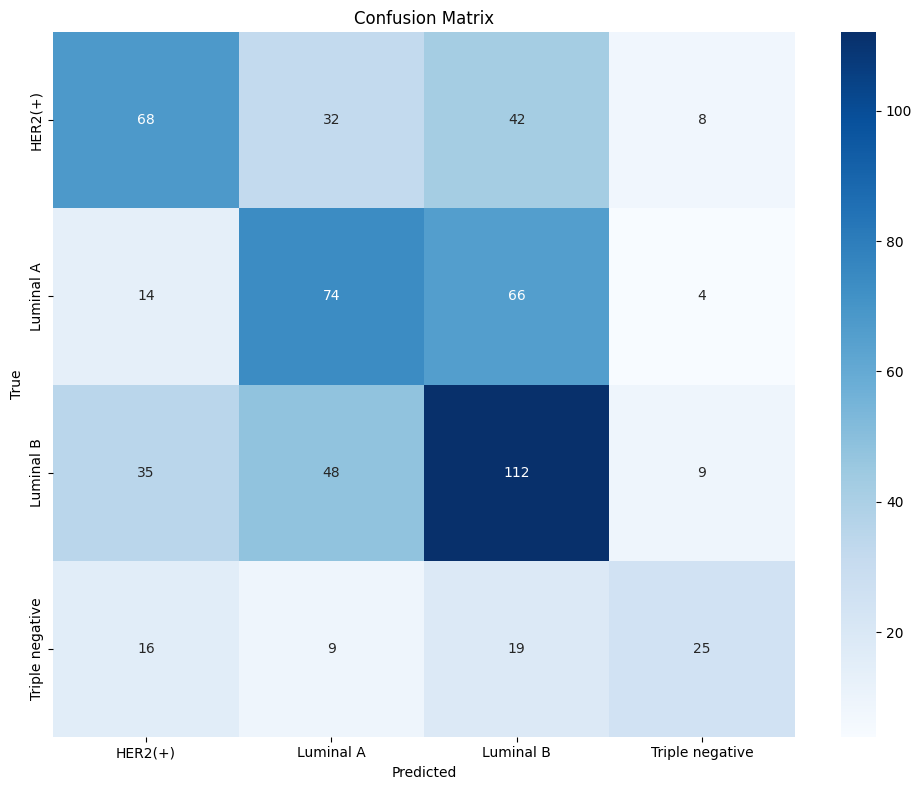


--- ERRORS: 302/581 (52.0%) ---

--- TOP 10 CONFIDENT MISCLASSIFICATIONS ---
  img_0469: True=Luminal A, Pred=Luminal B, Conf=87.6%
  img_0439: True=Luminal B, Pred=Luminal A, Conf=85.8%
  img_0331: True=HER2(+), Pred=Luminal A, Conf=85.3%
  img_0050: True=Triple negative, Pred=Luminal A, Conf=84.1%
  img_0471: True=HER2(+), Pred=Luminal B, Conf=84.1%
  img_0413: True=HER2(+), Pred=Luminal B, Conf=83.8%
  img_0429: True=HER2(+), Pred=Luminal B, Conf=83.3%
  img_0042: True=Luminal B, Pred=HER2(+), Conf=82.1%
  img_0056: True=Luminal A, Pred=HER2(+), Conf=80.9%
  img_0661: True=Luminal B, Pred=HER2(+), Conf=79.8%

✅ OOF F1 Score: 0.4802


In [28]:
def compute_mil_oof(train_bag_names, train_labels, mil_model_states, mil_params, feature_dim, features_dir):
    sgkf = StratifiedGroupKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
    oof_probs = np.zeros((len(train_bag_names), NUM_CLASSES))
    
    for fold_idx, (_, val_idx) in enumerate(sgkf.split(train_bag_names, train_labels, np.arange(len(train_bag_names)))):
        model = create_mil_model(feature_dim, mil_params)
        model.load_state_dict(strip_module_prefix(mil_model_states[fold_idx], model))
        model.eval()
        
        for vi in val_idx:
            feats = torch.from_numpy(np.load(features_dir / f'{train_bag_names[vi]}_original.npy')).float().unsqueeze(0).to(DEVICE)
            mask = torch.ones(1, feats.shape[1], dtype=torch.bool, device=DEVICE)
            with torch.no_grad():
                oof_probs[vi] = F.softmax(model(feats, mask), 1).cpu().numpy()[0]
        del model
    return oof_probs

if mil_model_states:
    print("Computing OOF predictions...")
    train_bag_names = list(set(idx.replace('.png','').replace('.jpg','') for idx in train_orig_indices))
    train_labels_arr = np.array([image_label_lookup[f"{n}.png"] for n in train_bag_names])
    
    config_path = FEATURES_DIR / 'config.json'
    if config_path.exists():
        config = json.load(open(config_path))
        feature_dim = config['feature_dim']
    else:
        feature_dim = 512
    
    oof_probs = compute_mil_oof(train_bag_names, train_labels_arr, mil_model_states, mil_params, feature_dim, FEATURES_DIR / 'features')
    oof_preds = oof_probs.argmax(1)
    
    cm, error_idx = analyze_errors(train_labels_arr, oof_preds, oof_probs, train_bag_names, CLASS_NAMES)
    
    oof_f1 = f1_score(train_labels_arr, oof_preds, average=F1_TYPE)
    print(f"\n✅ OOF F1 Score: {oof_f1:.4f}")
else:
    print("Train models first.")

In [29]:
if mil_model_states and len(error_idx) > 0:
    print(f"\n🔍 Visualizing top {min(5, len(error_idx))} misclassified samples...")
    sorted_errors = sorted(error_idx, key=lambda i: -oof_probs[i].max())[:5]
    
    config_path = FEATURES_DIR / 'config.json'
    if config_path.exists():
        config = json.load(open(config_path))
        feature_dim = config['feature_dim']
    else:
        feature_dim = 512
    
    for i in sorted_errors:
        bag_name = train_bag_names[i]
        true_label, pred_label = train_labels_arr[i], oof_preds[i]
        print(f"\n{'='*60}\n{bag_name} | True: {CLASS_NAMES[true_label]} | Pred: {CLASS_NAMES[pred_label]} (p={oof_probs[i][pred_label]:.2f})")
        
        feats = torch.from_numpy(np.load(FEATURES_DIR / 'features' / f'{bag_name}_original.npy')).float().unsqueeze(0).to(DEVICE)
        
        model = create_mil_model(feature_dim, mil_params)
        model.load_state_dict(strip_module_prefix(mil_model_states[0], model))
        model.eval()
        
        with torch.no_grad():
            mask = torch.ones(1, feats.shape[1], dtype=torch.bool, device=DEVICE)
            logits, attn_weights = model(feats, mask, return_attention=True)
        
        if attn_weights is not None:
            attn = attn_weights[0].cpu().numpy()
            top_k = min(5, len(attn))
            top_indices = np.argsort(attn)[-top_k:][::-1]
            print(f"Top attended patches: {[(idx, f'{attn[idx]:.3f}') for idx in top_indices]}")
        
        del model
else:
    print("No errors to visualize or models not trained.")


🔍 Visualizing top 5 misclassified samples...

img_0469 | True: Luminal A | Pred: Luminal B (p=0.88)


AttributeError: 'AttentionPool' object has no attribute 'attention_V'

In [ ]:
# Attention visualization: heatmaps for MIL attention
import math
from pathlib import Path

def _reshape_to_grid(attn):
    n = len(attn)
    s = int(math.sqrt(n))
    if s * s == n:
        return attn.reshape(s, s), (s, s)
    # try common rectangular grids (e.g., 14x16, 16x14, etc.)
    for r in range(max(1, s-4), s+5):
        if r > 0 and n % r == 0:
            c = n // r
            if r*c == n and r>1 and c>1:
                return attn.reshape(r, c), (r, c)
    # fallback: single row
    return attn.reshape(1, -1), (1, n)

def show_attention_heatmap(bag_name, tta_aug='original'):
    if not mil_model_states or not mil_params:
        print("⚠️ MIL models/params are not available. Run training first.")
        return
    
    # Build model from best params and first fold
    feature_dim = json.load(open(FEATURES_DIR / 'config.json')).get('feature_dim', 512)
    model = create_mil_model(feature_dim, mil_params, use_multi_gpu=False)
    state = mil_model_states[0]
    model.load_state_dict(strip_module_prefix(state, model))
    model.eval()
    
    # Load features for the selected bag
    feat_file = Path(FEATURES_DIR) / 'features' / f"{bag_name}_{tta_aug}.npy"
    if not feat_file.exists():
        feat_file = Path(FEATURES_DIR) / 'features' / f"{bag_name}_original.npy"
    feats = torch.from_numpy(np.load(feat_file)).float().unsqueeze(0).to(DEVICE)
    mask = torch.ones(1, feats.shape[1], dtype=torch.bool, device=DEVICE)
    
    # Forward with attention
    with torch.no_grad():
        logits, attn = model(feats, mask, return_attention=True)
        probs = F.softmax(logits, 1).cpu().numpy()[0]
        attn_np = attn.cpu().numpy()[0]
    
    pred_cls = IDX_TO_CLASS[int(np.argmax(probs))]
    conf = float(np.max(probs))
    print(f"Bag: {bag_name} | Pred: {pred_cls} ({conf*100:.1f}%) | patches: {len(attn_np)}")
    
    # Plot 1D attention bars
    plt.figure(figsize=(12, 3))
    plt.bar(range(len(attn_np)), attn_np, color='steelblue')
    plt.xlabel('Patch Index')
    plt.ylabel('Attention Weight')
    plt.title(f'Attention Weights (1D) — {bag_name}')
    plt.tight_layout()
    plt.show()
    
    # Plot heatmap if grid-like
    grid, shape = _reshape_to_grid(attn_np)
    plt.figure(figsize=(min(12, 0.6*shape[1]+2), min(10, 0.6*shape[0]+2)))
    sns.heatmap(grid, cmap='magma', cbar=True)
    plt.title(f'Attention Heatmap ({shape[0]}x{shape[1]}) — {bag_name}')
    plt.xlabel('Cols')
    plt.ylabel('Rows')
    plt.tight_layout()
    plt.show()
    
    return {'bag': bag_name, 'pred': pred_cls, 'confidence': conf, 'shape': shape}

## Example usage (set a bag present in cached features)
# example_bag = '000123'  # without extension
# show_attention_heatmap(example_bag)